In [10]:
from qiskit import QuantumCircuit
from collections import OrderedDict


def baseline_adder_subtractor_core():
    """
    Baseline reversible quantum adder-cum-subtractor.

    q0 = A
    q1 = B
    q2 = Mode
         0 -> Addition
         1 -> Subtraction
    q3 = Result
    q4 = Carry/Borrow
    """

    qc = QuantumCircuit(5)

    # B' = B XOR Mode
    qc.cx(2, 1)

    # Result = A XOR B' XOR Mode
    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    # Carry calculation
    qc.ccx(0, 1, 4)
    qc.ccx(0, 2, 4)
    qc.ccx(1, 2, 4)

    # Carry -> Borrow for subtraction
    qc.cx(2, 4)

    # Restore original B
    qc.cx(2, 1)

    return qc

In [11]:
qc = baseline_adder_subtractor_core()

print(qc)

                                                  
q_0: ───────■──────────────■────■─────────────────
     ┌───┐  │              │    │            ┌───┐
q_1: ┤ X ├──┼────■─────────■────┼────■───────┤ X ├
     └─┬─┘  │    │         │    │    │       └─┬─┘
q_2: ──■────┼────┼────■────┼────■────■────■────■──
          ┌─┴─┐┌─┴─┐┌─┴─┐  │    │    │    │       
q_3: ─────┤ X ├┤ X ├┤ X ├──┼────┼────┼────┼───────
          └───┘└───┘└───┘┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐     
q_4: ────────────────────┤ X ├┤ X ├┤ X ├┤ X ├─────
                         └───┘└───┘└───┘└───┘     


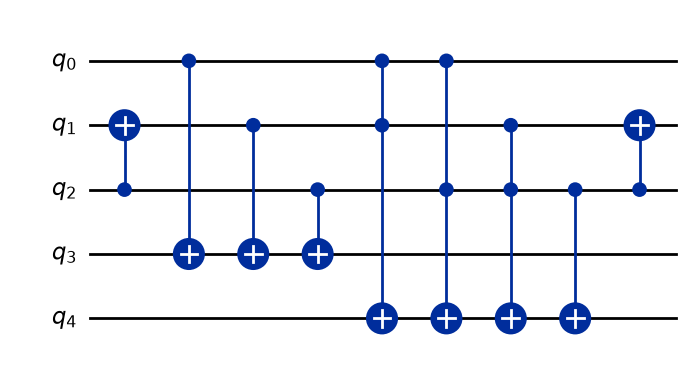

In [12]:
qc.draw("mpl", fold=-1)

In [13]:
print("Number of qubits:", qc.num_qubits)
print("Circuit depth:", qc.depth())
print("Gate count:", qc.count_ops())

Number of qubits: 5
Circuit depth: 7
Gate count: OrderedDict({'cx': 6, 'ccx': 3})


In [14]:
gate_counts = qc.count_ops()

non_measurement_gate_count = sum(
    count
    for gate, count in gate_counts.items()
    if gate != "measure"
)

print("Non-measurement gate count:", non_measurement_gate_count)

Non-measurement gate count: 9


In [15]:
print("===== BASELINE ADDER-CUM-SUBTRACTOR =====")
print("Number of qubits       :", qc.num_qubits)
print("Circuit depth          :", qc.depth())
print("Total gate count       :", non_measurement_gate_count)
print("CNOT gates (CX)        :", gate_counts.get("cx", 0))
print("Toffoli gates (CCX)    :", gate_counts.get("ccx", 0))

===== BASELINE ADDER-CUM-SUBTRACTOR =====
Number of qubits       : 5
Circuit depth          : 7
Total gate count       : 9
CNOT gates (CX)        : 6
Toffoli gates (CCX)    : 3


In [16]:
import pandas as pd

In [17]:
results = {
    "Circuit": ["Baseline Adder-Cum-Subtractor"],
    "Qubits": [qc.num_qubits],
    "Depth": [qc.depth()],
    "Total_Gates": [non_measurement_gate_count],
    "CNOT_Count": [gate_counts.get("cx", 0)],
    "Toffoli_Count": [gate_counts.get("ccx", 0)]
}

df = pd.DataFrame(results)

df

,Circuit,Qubits,Depth,Total_Gates,CNOT_Count,Toffoli_Count
0,Baseline Adder-Cum-Subtractor,5,7,9,6,3


In [18]:
df.to_csv(
    "../results/tables/baseline_results.csv",
    index=False
)

print("Baseline results saved successfully.")

Baseline results saved successfully.


In [19]:
fig = qc.draw("mpl", fold=-1)

fig.savefig(
    "../results/circuits/baseline_adder_subtractor.png",
    dpi=300,
    bbox_inches="tight"
)

print("Circuit image saved successfully.")

Circuit image saved successfully.
